### Building a Chatbot Memory System
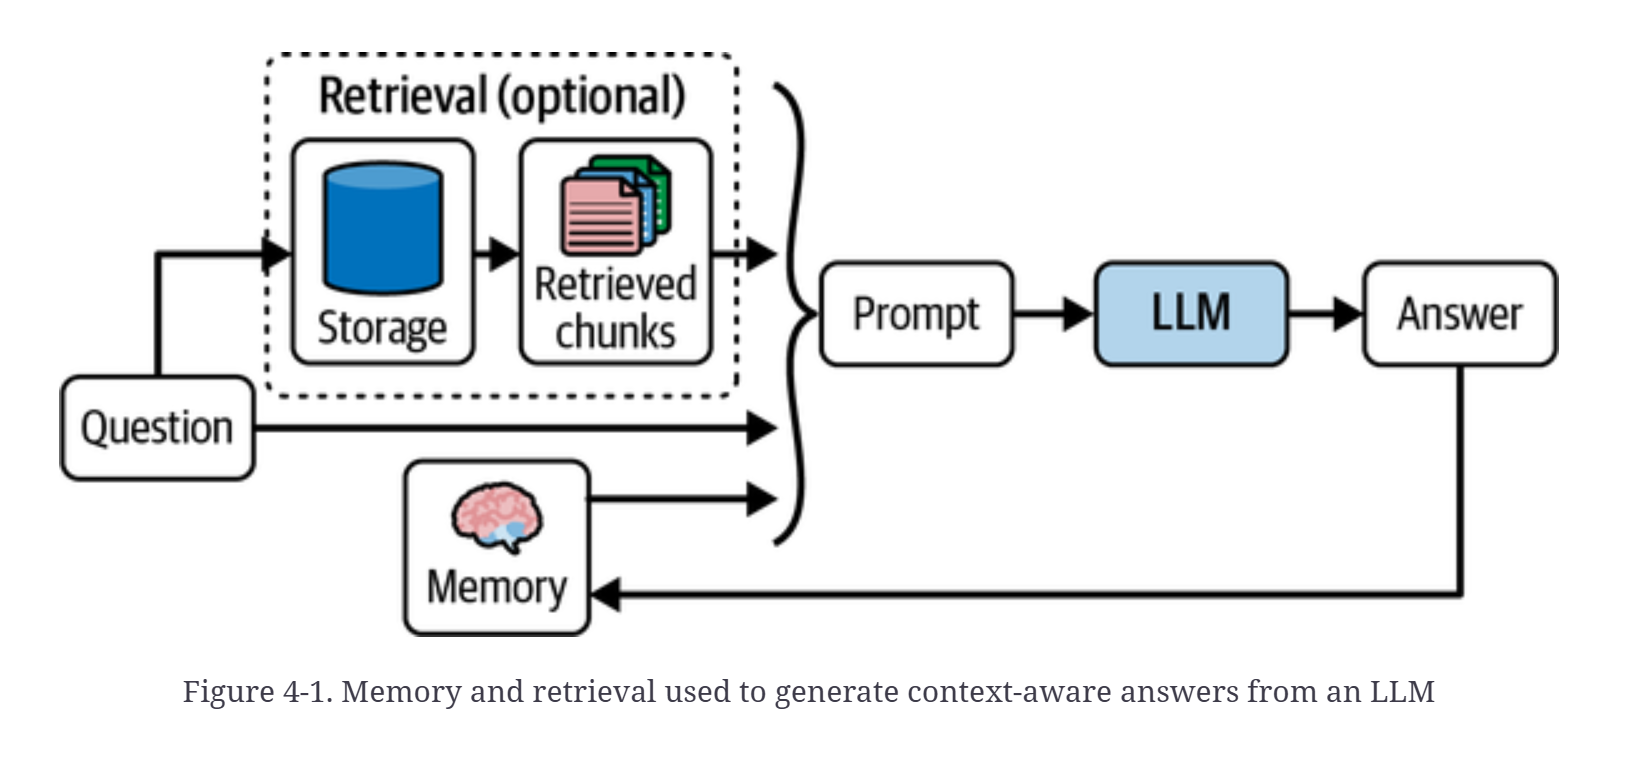

In [7]:
from dotenv import load_dotenv
import os
load_dotenv()
GoogleGeminiKey = os.getenv('GOOGLE_GEMINI_KEY')

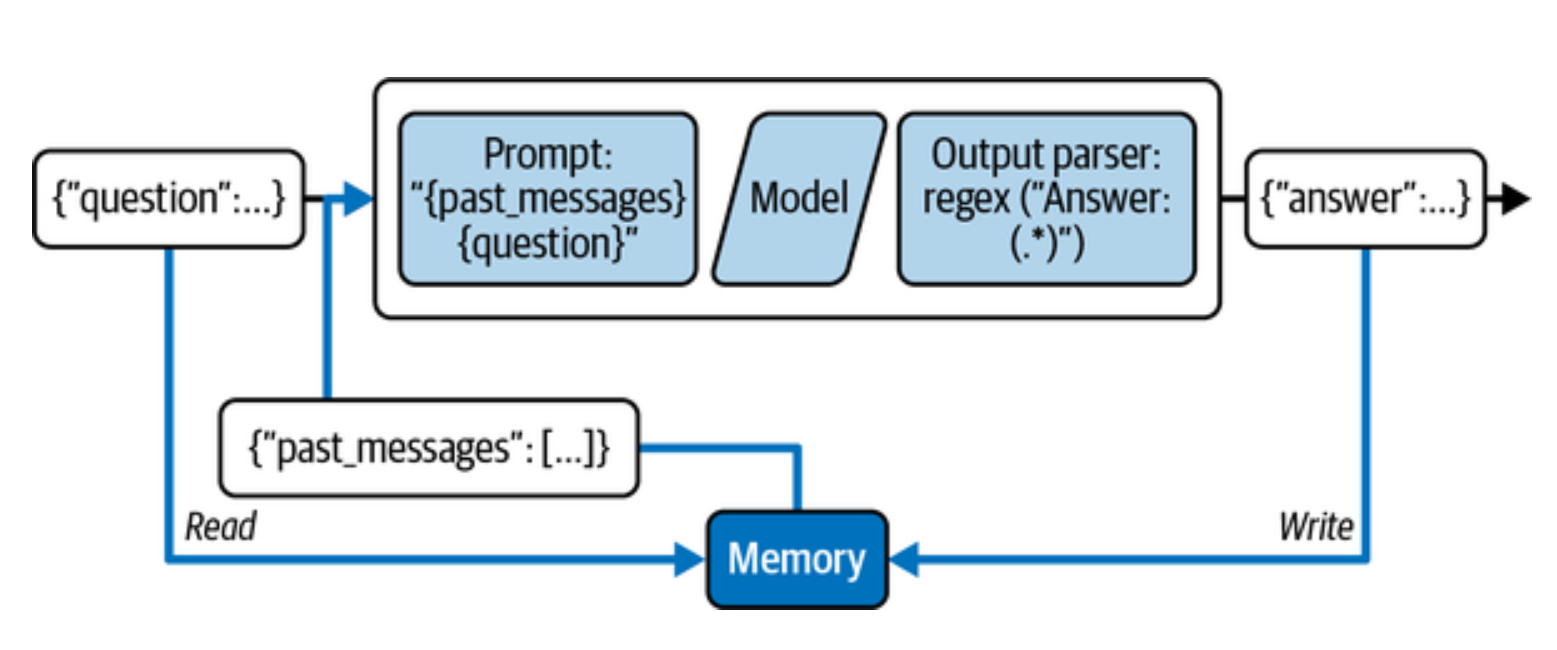
Here’s a code example that illustrates a simple version of this memory system using LangChain:

In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-001",
    api_key=GoogleGeminiKey,
)

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant who can answer questions about history, science, and technology."),
    ("placeholder", "{messages}"),
])

chain = prompt | model

answer = chain.invoke({"messages": [("human", """Translate this sentence from English to French: I love 
            programming."""), ("ai", "J'adore programmer."), ("human", "What did you just say?")]})

print(answer.content)


I translated the English sentence "I love programming" into French. The French translation is "J'adore programmer."


While this is simple and it works, when taking your application to production, you’ll face some more challenges related to managing memory at scale, such as:

You’ll need to update the memory after every interaction, atomically (i.e., don’t record only the question or only the answer in the case of failure).

You’ll want to store these memories in durable storage, such as a relational database.

You’ll want to control how many and which messages are stored for later, and how many of these are used for new interactions.

You’ll want to inspect and modify this state (for now, just a list of messages) outside a call to an LLM.

# LangGraph

Each graph is then made up of the following:

<b>State</b>

The data received from outside the application, modified and produced by the application while it’s running.

<b>Nodes</b>

Each step to be taken. Nodes are simply Python/JS functions, which receive the current state as input and can return an update to that state (that is, they can add to it and modify or remove existing data).

<b>Edges</b>

The connections between nodes. Edges determine the path taken from the first node to the last, and they can be fixed (that is, after Node B, always visit node D) or conditional (evaluate a function to decide the next node to visit after node C).

In [9]:
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list,add_messages]

builder = StateGraph(State)

In [10]:
def chatbot(state: State):
    answer = model.invoke(state["messages"])
    return {"messages": [answer]}

builder.add_node("chatbot", chatbot)

In [11]:
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)
graph = builder.compile()

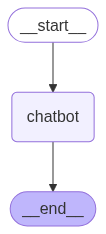

In [12]:
from IPython.display import display
from PIL import Image
import io

def display_image(img_bytes):
    # Convert bytes to an image
    image = Image.open(io.BytesIO(img_bytes))

    # Display the image in the notebook
    display(image)

display_image(graph.get_graph().draw_mermaid_png())

In [13]:
from langchain_core.messages import HumanMessage
while True:
    q = input("Enter your question: ")
    if(q=="exit"):
        break
    i = {"messages":[HumanMessage(content=q)]}
    for chunk in graph.stream(i):
        print(chunk['chatbot']['messages'][0].content)


Hi there! How can I help you today?
Okay, Alex! It's nice to meet you. Is there anything I can help you with today?
As an AI, I have no memory of past conversations. Therefore, I don't know your name. You haven't told me!


In [22]:
from langgraph.checkpoint.memory import MemorySaver
graph = builder.compile(checkpointer=MemorySaver())

In [33]:
thread1 = {"configurable": {"thread_id": "1"}}
result_1 = graph.invoke(
    { "messages": [HumanMessage("hi, my name is Jack!")] }, 
    thread1
)

result_2 = graph.invoke(
    { "messages": [HumanMessage("what is my name?")] }, 
    thread1
)
for message in result_2['messages']:
    print(message.content)

hi, my name is Jack!
Hi Jack! It's nice to meet you. How can I help you today?
what is my name?
Your name is Jack. You just told me! 😊
hi, my name is Jack!
Hi Jack! Nice to meet you again! How can I help you today?
what is my name?
You told me your name is Jack. Is that right?


In [34]:
from langchain_core.messages import HumanMessage
thread2 = {"configurable": {"thread_id": "2"}}
while True:
    q = input("Enter your question: ")
    if(q=="exit"):
        break
    i = {"messages":[HumanMessage(content=q)]}
    print(f'user : {q}')
    res = graph.invoke(i, thread2)
    print(f'chatbot : {res["messages"][-1].content}')


user : Hi my name bob
chatbot : Hi Bob, it's nice to meet you! How can I help you today?
user : make 5 day gym plan with diet for bulking for a vegitarian man
chatbot : Okay Bob, here's a 5-day gym plan and a sample vegetarian bulking diet. Remember, this is a general plan, and you should adjust it based on your individual needs, experience level, and any pre-existing conditions. **Consult with a doctor or registered dietitian before starting any new diet or exercise program.**

**Key Considerations for Vegetarian Bulking:**

*   **Protein:** This is the most crucial aspect. Vegetarians need to be mindful of combining different protein sources to get all the essential amino acids.
*   **Calories:** You need a calorie surplus (eating more than you burn) to build muscle. Aim for 250-500 calories above your maintenance level. Track your intake to ensure you're hitting your goals.
*   **Carbohydrates:** Important for energy and muscle glycogen replenishment. Focus on complex carbs.
*   **H

#### Modifying Chat History
Three main ways: trimming, filtering, and merging messages.

#### Trimming Messages
LLMs have limited context windows; in other words, there is a maximum number of tokens that LLMs can receive as a prompt. As such, the final prompt sent to the model shouldn’t exceed that limit (particular to each mode), as models will either refuse an overly long prompt or truncate it. In addition, excessive prompt information can distract the model and lead to hallucination.
<br/>

An effective solution to this problem is to limit the number of messages that are retrieved from chat history and appended to the prompt. In practice, we need only to load and store the most recent messages. Let’s use an example chat history with some preloaded messages.



In [36]:
from langchain_core.messages import SystemMessage,AIMessage, trim_messages

trimmer = trim_messages(
    max_tokens=65,
    strategy='last',
    token_counter=ChatGoogleGenerativeAI(api_key=GoogleGeminiKey,model="gemini-2.0-flash-001"),
    include_system=True,
    allow_partial=False,
    start_on="human"
)

messages = [
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="what's 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

trimmer.invoke(messages)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}),
 HumanMessage(content="hi! I'm bob", additional_kwargs={}, response_metadata={}),
 AIMessage(content='hi!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='I like vanilla ice cream', additional_kwargs={}, response_metadata={}),
 AIMessage(content='nice', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="what's 2 + 2", additional_kwargs={}, response_metadata={}),
 AIMessage(content='4', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}),
 AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='yes!', additional_kwargs={}, response_metadata={})]

In [ ]:
graph.get_state(thread2).values['messages']

[HumanMessage(content='Hi my name bob', additional_kwargs={}, response_metadata={}, id='722474a4-c102-475e-9110-37fffa0078f7'),
 AIMessage(content="Hi Bob, it's nice to meet you! How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--5bd5962a-9d49-4e04-b94b-597a07d9a067-0', usage_metadata={'input_tokens': 4, 'output_tokens': 19, 'total_tokens': 23, 'input_token_details': {'cache_read': 0}}),
 HumanMessage(content='make 5 day gym plan with diet for bulking for a vegitarian man', additional_kwargs={}, response_metadata={}, id='3a3fd08a-3921-4a92-8724-0e71b483545d'),
 AIMessage(content="Okay Bob, here's a 5-day gym plan and a sample vegetarian bulking diet. Remember, this is a general plan, and you should adjust it based on your individual needs, experience level, and any pre-existing conditions. **Consult with a doctor 

In [40]:
trimmer.invoke(graph.get_state(thread2).values['messages'])

[HumanMessage(content='thank you', additional_kwargs={}, response_metadata={}, id='3d723109-b6e7-4d79-b232-86ac7d4cfe35'),
 AIMessage(content="You're very welcome, Bob! I'm glad I could help. Feel free to reach out if you have any more questions along the way. Best of luck with your training and diet!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--e3bd20ac-25a2-4b99-995f-6d1aac5b2c44-0', usage_metadata={'input_tokens': 2108, 'output_tokens': 41, 'total_tokens': 2149, 'input_token_details': {'cache_read': 0}})]

The parameter **strategy** controls whether to start from the beginning or the end of the list. Usually, you’ll want to prioritize the most recent messages and cut older messages if they don’t fit. That is, start from the end of the list. For this behavior, choose the value **last**. The other available option is **first**, which would prioritize the oldest messages and cut more recent messages if they don’t fit.

The **token_counter** is an LLM or chat model, which will be used to count tokens using the tokenizer appropriate to that model.

We can add the parameter **include_system**=True to ensure that the trimmer keeps the system message.

The parameter **allow_partial** determines whether to cut the last message’s content to fit within the limit. In our example, we set this to false, which completely removes the message that would send the total over the limit.

The parameter **start_on**="human" ensures that we never remove an AIMessage (that is, a response from the model) without also removing a corresponding HumanMessage (the question for that response).

**Filtering Messages**
As the list of chat history messages grows, a wider variety of types, subchains, and models may be utilized. LangChain’s filter_messages helper makes it easier to filter the chat history messages by type, ID, or name.

In [42]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage,filter_messages

messages = [
    SystemMessage("you are a good assistant", id="1"),
    HumanMessage("example input", id="2", name="example_user"),
    AIMessage("example output", id="3", name="example_assistant"),
    HumanMessage("real input", id="4", name="bob"),
    AIMessage("real output", id="5", name="alice"),
]
filtered_messages = filter_messages(messages, include_types='human')
print(filtered_messages)

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'), HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4')]


In [43]:
filter_messages(messages, exclude_names=["example_user", "example_assistant"])

[SystemMessage(content='you are a good assistant', additional_kwargs={}, response_metadata={}, id='1'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5')]

In [44]:
filter_messages(
    messages, 
    include_types=[HumanMessage, AIMessage], 
    exclude_ids=["3"]
)

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5')]

**Merging Consecutive Messages**
Certain models don’t support inputs, including consecutive messages of the same type (for instance, Anthropic chat models). LangChain’s merge_message_runs utility makes it easy to merge consecutive messages of the same type

In [45]:
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    merge_message_runs,
)

messages = [
    SystemMessage("you're a good assistant."),
    SystemMessage("you always respond with a joke."),
    HumanMessage(
        [{"type": "text", "text": "i wonder why it's called langchain"}]
    ),
    HumanMessage("and who is harrison chasing anyway"),
    AIMessage(
        '''Well, I guess they thought "WordRope" and "SentenceString" just 
        didn\'t have the same ring to it!'''
    ),
    AIMessage("""Why, he's probably chasing after the last cup of coffee in the 
        office!"""),
]

merge_message_runs(messages)

[SystemMessage(content="you're a good assistant.\nyou always respond with a joke.", additional_kwargs={}, response_metadata={}),
 HumanMessage(content=[{'type': 'text', 'text': "i wonder why it's called langchain"}, 'and who is harrison chasing anyway'], additional_kwargs={}, response_metadata={}),
 AIMessage(content='Well, I guess they thought "WordRope" and "SentenceString" just \n        didn\'t have the same ring to it!\nWhy, he\'s probably chasing after the last cup of coffee in the \n        office!', additional_kwargs={}, response_metadata={})]